# 时间序列预测模型：完整流程与代码实现

> **预测类模型——时间序列整理笔记**
> 本笔记覆盖时间序列建模的完整路线：**传统统计 → 机器学习 → 深度学习**，含原理、公式与配套代码实例；代码风格参考《代码基础》讲义。

**核心思想**：时间序列预测的本质，是利用历史数据中蕴含的**时间依赖结构**（趋势、季节、周期性、自相关）来外推未来：

$$
\text{历史序列 } y_1, y_2, \ldots, y_T \xrightarrow{\text{提取时间结构}} \hat{y}_{T+1}, \hat{y}_{T+2}, \ldots
$$

**建模路线总览**（本笔记的骨架）：

```
传统统计模型（指数平滑 / ARIMA）──▶ 机器学习（XGBoost / LightGBM）──▶ 深度学习（LSTM / Transformer）
   可解释、数据需求低                       精度高、特征灵活                   擅长长序列、大数据
```

> <span style="color:#c0392b">**⚠️ 竞赛忠告**：不需要记住全部公式，**关键是掌握建模流程与验证方式**；用普通模型很难拿高奖，比赛拉开差距的往往是验证方式与细节处理（见第五章）。</span>

## 目录

| 章节 | 内容 |
|:---:|------|
| 一 | 时间序列基础：结构分解、平稳性(ADF)、ACF/PACF |
| 二 | 经典统计模型：基线、指数平滑、AR/MA、ARIMA/SARIMA、模型检验 |
| 三 | 机器学习模型：滑动窗口特征、树模型(XGBoost/LightGBM)、时序交叉验证 |
| 四 | 深度学习模型：LSTM、Transformer 及变体（了解为主） |
| 五 | 完整建模流程与实战案例（共享单车日需求预测） |
| 六 | 比赛注意事项、选题建议与论文写作要点 |

# 准备工作：运行环境与演示案例

## 运行环境

- Python 3.9+，依赖库：`numpy`、`pandas`、`matplotlib`、`statsmodels`、`scikit-learn`（树模型可选 `xgboost` / `lightgbm`，深度模型可选 `torch`）
- 本 notebook 代码**自包含、按顺序运行**即可复现全部结果

## 演示案例（贯穿全文）

以案例 **"共享单车日需求预测"** 为例：

> 某共享单车系统记录了 **2022-01-01** 起的**每日租借量**及气温、降雨、节假日、周末、大型活动、车辆供给等外生变量，目标是预测未来 30~60 天的日租借量。

- 数据：`共享单车日需求.csv`（配套数据文件），含少量**气象缺失**与**系统异常日**
- 关键点：日数据存在**以周为周期**的季节性（工作日/周末差异明显）、气温等外生影响、节假日脉冲

**数据清洗原则**：气象变量线性插值；系统异常日用**前后 28 天同星期几的中位数**替换（保留信息而非删除整行）。

In [1]:
# ============================================================
# 准备工作：导入库 + 案例数据（共享单车日需求.csv）
# ============================================================

# 强制内联绘图后端：避免无图形界面环境（如终端/服务器）下
# 打开 Qt 绘图窗口导致内核崩溃；notebook 中图像仍以内联方式展示
%matplotlib inline

# 导入所需库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 中文字体与绘图设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# 数据路径（迁移到新问题时改成自己的路径）
DATA_FILE = r"C:\mathwork\PPT\课程14：课件&资料\共享单车日需求.csv"

def load_data(path=DATA_FILE):
    """读取数据：自动尝试 utf-8-sig / gbk 编码，并完成基础清洗。"""
    try:
        df = pd.read_csv(path, encoding="utf-8-sig", parse_dates=["日期"])
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="gbk", parse_dates=["日期"])
    df = df.sort_values("日期").reset_index(drop=True)

    # 1) 气象缺失：线性插值（用时间上相邻的值填充）
    df["平均气温_C"] = df["平均气温_C"].interpolate(limit_direction="both")
    df["降雨量_mm"] = df["降雨量_mm"].interpolate(limit_direction="both")

    # 2) 系统异常日：用前后 28 天内同星期几的正常值中位数替换
    df["租借量_清洗"] = df["租借量"].astype(float)
    for i in df.index[df["系统异常标记"] == 1]:
        window = df.iloc[max(0, i - 28): min(len(df), i + 29)]
        same_weekday = window[(window["日期"].dt.dayofweek == df.loc[i, "日期"].dayofweek)
                              & (window["系统异常标记"] == 0)]
        df.loc[i, "租借量_清洗"] = same_weekday["租借量"].median()
    return df

df = load_data()
print("数据范围：", df["日期"].min().date(), "→", df["日期"].max().date(), "，共", len(df), "天")
display(df.head())

数据范围： 2022-01-01 → 2025-12-31 ，共 1461 天


,日期,租借量,平均气温_C,降雨量_mm,节假日,周末,大型活动,车辆供给指数,系统异常标记,租借量_清洗
0,2022-01-01,350,3.9,0.0,1,1,0,1.0,0,350.0
1,2022-01-02,350,3.1,0.0,0,1,0,1.0,0,350.0
2,2022-01-03,474,3.9,0.0,0,0,0,1.0,0,474.0
3,2022-01-04,350,1.5,0.0,0,0,0,1.0,0,350.0
4,2022-01-05,579,4.0,1.4,0,0,0,1.0,0,579.0


---
# 一、时间序列基础

## 1.1 序列的结构分解

任何时间序列都可以分解为四个基本成分：

| 成分 | 符号 | 含义 | 示例 |
|------|:---:|------|------|
| **趋势** $T_t$ | T | 长期单调变化方向 | 逐年上升 |
| **季节** $S_t$ | S | **固定周期**的重复模式 | 以 7 天为周期的周内波动 |
| **循环** $C_t$ | C | 周期**不固定**的波动 | 经济周期 |
| **残差** $I_t$ | I | 随机波动（白噪声） | 不可解释部分 |

两种组合方式：

$$加法模型：\quad y_t = T_t + S_t + C_t + I_t \qquad（各成分相互独立，波动幅度不随时间变化）$$

$$乘法模型：\quad y_t = T_t \times S_t \times C_t \times I_t \qquad（波动幅度随水平变化，常见于需求/经济数据）$$

> <span style="color:#c0392b">**⚠️ 注意**：**季节**与**循环**的区别——季节是固定周期（周、月、年），循环是不固定周期的长期波动；实际建模中循环往往并入趋势处理。</span>

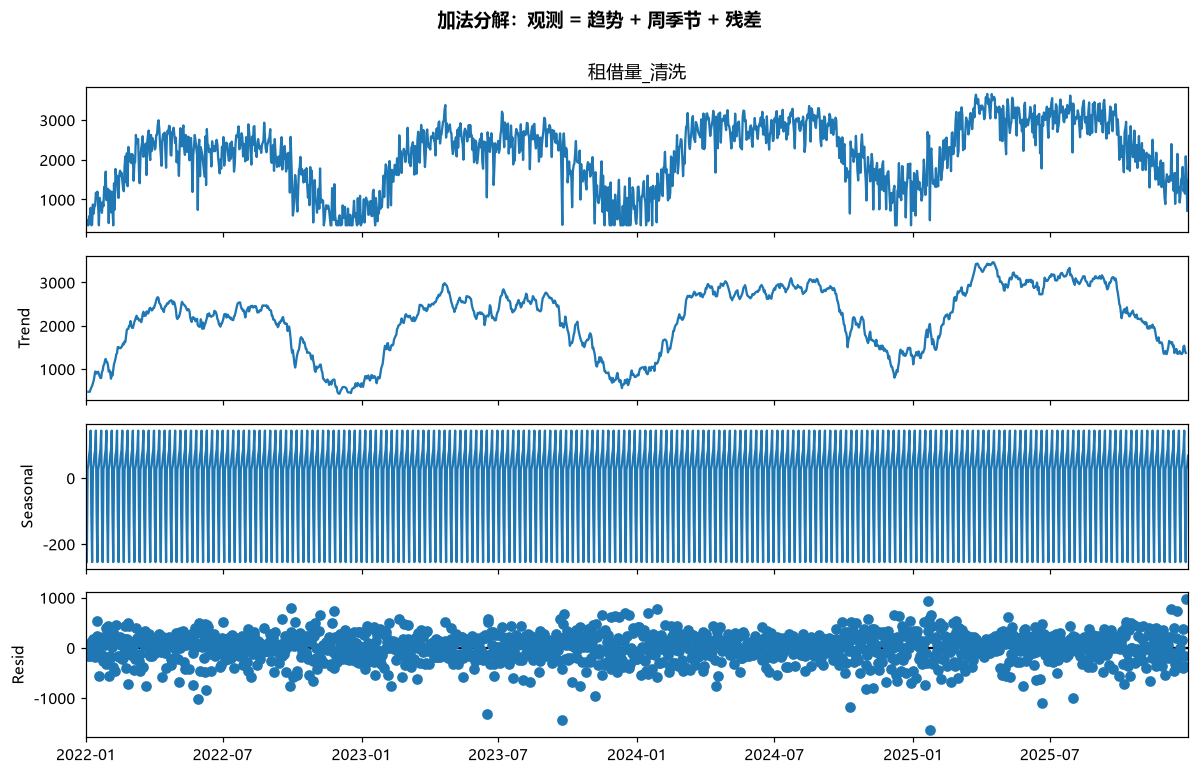

In [2]:
# 1.1 序列分解：验证趋势与周季节成分
from statsmodels.tsa.seasonal import seasonal_decompose

series = df.set_index("日期")["租借量_清洗"]
res = seasonal_decompose(series, model="additive", period=7)   # period=7 表示周季节

fig = res.plot()
fig.set_size_inches(11, 7)
plt.suptitle("加法分解：观测 = 趋势 + 周季节 + 残差", y=1.0, fontweight="bold")
plt.tight_layout(); plt.show()

## 1.2 平稳性：经典模型的地基

**为什么重要**：经典统计模型（AR、MA、ARIMA）都要求序列**平稳**——平稳序列的**均值、方差、自协方差不随时间改变**，统计性质稳定，才能把过去的规律外推到未来；非平稳序列直接建模会产生**虚假回归**。

**弱平稳（宽平稳）定义**：

$$E(y_t) = \mu \ (\text{常数}), \qquad Var(y_t) = \sigma^2 < \infty, \qquad Cov(y_t, y_{t-k}) = \gamma_k \ (\text{只与滞后 } k \text{ 有关})$$

### 单位根检验（ADF 检验）

ADF 检验回归方程：$\Delta y_t = \alpha + \beta y_{t-1} + \sum_{k=1}^{p} \gamma_k \Delta y_{t-k} + \varepsilon_t$

- 原假设 $H_0: \beta = 0$（存在单位根 → **非平稳**）；备择假设 $H_1: \beta < 0$（平稳）
- 判断规则：**p 值 < 0.05 拒绝原假设 → 序列平稳**

### 常用平稳化处理

| 方法 | 公式 | 适用 |
|------|------|------|
| **一阶差分** | $\Delta y_t = y_t - y_{t-1}$ | 去除线性趋势（最常用） |
| 取对数 | $z_t = \ln y_t$ | 稳定方差、处理指数增长 |
| 去季节 | $y_t - \hat{S}_t$ | 去除固定周期成分 |

> <span style="color:#c0392b">**⚠️ 检验顺序**：先画趋势图 → 再做 ADF 检验 → 不平稳就差分 → 差分后再检验，直到平稳（差分阶数记为 $d$）。</span>

In [3]:
# 1.2 ADF 单位根检验：原序列 vs 一阶差分
from statsmodels.tsa.stattools import adfuller

def adf_report(s, name):
    stat, p = adfuller(s, autolag="AIC")[:2]
    verdict = "平稳" if p < 0.05 else "非平稳"
    print(f"{name:10s}  ADF = {stat:8.4f}   p = {p:.4f}  →  {verdict}")

y = df["租借量_清洗"]
adf_report(y, "原序列")
adf_report(y.diff().dropna(), "一阶差分")

原序列         ADF =  -2.5290   p = 0.1086  →  非平稳
一阶差分        ADF =  -8.1223   p = 0.0000  →  平稳


## 1.3 自相关 ACF 与偏自相关 PACF

- **ACF（自相关函数）**：度量 $y_t$ 与 $y_{t-k}$ 的相关性（含中间滞后的间接影响）：

$$\rho_k = \frac{Cov(y_t, y_{t-k})}{Var(y_t)} = \frac{\sum_{t=k+1}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}$$

- **PACF（偏自相关函数）**：剔除中间滞后影响后，$y_t$ 与 $y_{t-k}$ 的**净**相关

**用途（ARIMA 定阶的核心工具）**：

| 特征 | 模型 | 说明 |
|------|------|------|
| PACF 在 $p$ 阶后**截尾** | AR($p$) | 用 PACF 定 $p$ |
| ACF 在 $q$ 阶后**截尾** | MA($q$) | 用 ACF 定 $q$ |
| 两者都**拖尾**（缓慢衰减） | ARMA | 需结合信息准则定阶 |

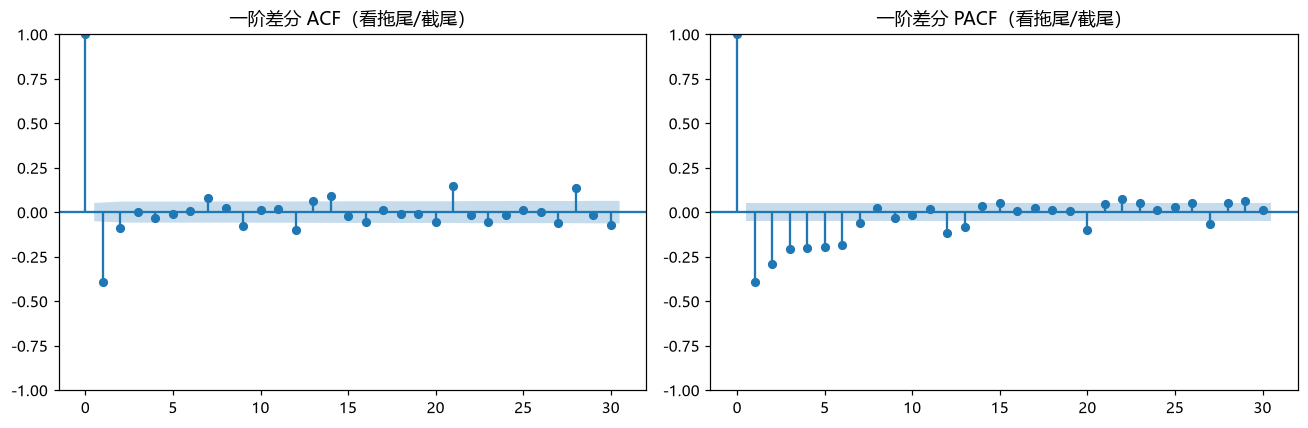

In [4]:
# 1.3 ACF 与 PACF：对一阶差分序列观察截尾/拖尾
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

d = y.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(d, ax=axes[0], lags=30); axes[0].set_title("一阶差分 ACF（看拖尾/截尾）")
plot_pacf(d, ax=axes[1], lags=30); axes[1].set_title("一阶差分 PACF（看拖尾/截尾）")
plt.tight_layout(); plt.show()

---
# 二、经典统计模型

> 经典模型是比赛的**必备对照**：可解释性强、数据需求低、能给出预测区间；通常作为"基线"与机器学习/深度学习模型对比，证明复杂模型的必要性。

## 2.1 基线模型（朴素对照）

最朴素的预测，用于给其他模型"兜底"：

| 模型 | 公式 | 思想 |
|------|------|------|
| 朴素法 | $\hat{y}_{T+h} = y_T$ | 未来 = 最后一个观测 |
| 季节朴素法 | $\hat{y}_{T+h} = y_{T+h-m}$ | 未来 = 上周/去年同期同时刻 |
| 移动平均 | $\hat{y}_{T+h} = \dfrac{1}{k}\sum_{i=0}^{k-1} y_{T-i}$ | 未来 = 最近 $k$ 期平均 |

**评价指标**（贯穿全文，比赛必用）：

$$MAE = \frac{1}{n}\sum_{t=1}^{n} |e_t|, \qquad RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n} e_t^2}, \qquad MAPE = \frac{1}{n}\sum_{t=1}^{n} \frac{|e_t|}{|y_t|} \times 100\%$$

> <span style="color:#c0392b">**⚠️ 竞赛技巧**：论文中一定要放 1~2 个基线模型作对照——如果复杂模型连朴素法都打不过，说明特征或模型方向有问题。</span>

In [5]:
# 2.1 基线模型 + 误差指标（numpy 自实现，不依赖额外库）
def forecast_metrics(actual, forecast):
    """返回 MAE / RMSE / MAPE(%)。"""
    e = np.asarray(forecast) - np.asarray(actual)
    return dict(MAE=float(np.mean(np.abs(e))),
                RMSE=float(np.sqrt(np.mean(e ** 2))),
                MAPE=float(np.mean(np.abs(e) / np.clip(np.abs(actual), 1, None)) * 100))

def naive_forecast(train, h):
    """朴素法：未来全部等于最后一个值。"""
    return np.repeat(float(train[-1]), h)

def seasonal_naive_forecast(train, h, m=7):
    """季节朴素法：重复最后一个完整周期（周）。"""
    return np.resize(np.asarray(train[-m:]), h)

def moving_average_forecast(train, h, k=7):
    """移动平均：未来全部等于最近 k 天的均值。"""
    return np.repeat(float(np.mean(train[-k:])), h)

# 演示：以最后 60 天为测试集
y_train, y_test = y.iloc[:-60], y.iloc[-60:]
rows = []
for name, fc in [("朴素法", naive_forecast(y_train.values, 60)),
                 ("季节朴素(7)", seasonal_naive_forecast(y_train.values, 60)),
                 ("7日均线", moving_average_forecast(y_train.values, 60))]:
    rows.append({"模型": name, **forecast_metrics(y_test.values, fc)})
print("=== 基线模型：最后 60 天测试集 ===")
print(pd.DataFrame(rows).sort_values("RMSE").to_string(index=False))

=== 基线模型：最后 60 天测试集 ===
     模型        MAE       RMSE      MAPE
    朴素法 356.133333 418.833817 26.115500
   7日均线 547.695238 660.740509 42.896079
季节朴素(7) 586.183333 709.633908 44.634670


## 2.2 指数平滑

思想：**越近的历史越重要**，权重按指数衰减。

### 简单指数平滑（SES，单指数）
$$\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}, \qquad \hat{y}_{t+1} = \ell_t$$

### 霍尔特线性趋势模型（Holt，双指数）
$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)b_{t-1}$$
$$\hat{y}_{t+h} = \ell_t + h \cdot b_t$$

### 霍尔特-温特斯模型（Holt-Winters，三指数：水平 + 趋势 + 季节）
加法季节形式（乘法形式把 $+S$ 换成 $\times S$，适用于波动幅度随水平变化的数据）：

$$\ell_t = \alpha (y_t - S_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)b_{t-1}$$
$$S_t = \gamma (y_t - \ell_t) + (1-\gamma)S_{t-m}$$
$$\hat{y}_{t+h} = \ell_t + h b_t + S_{t-m+h}$$

参数 $\alpha, \beta, \gamma$ 用**网格搜索最小化 SSE** 自动确定；季节形式（加/乘）**先判断周期、观察波动幅度**再选择。

In [6]:
# 2.2 Holt-Winters：statsmodels 一行拟合（参数自动优化）
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# trend/seasonal 可选 "add" 或 "mul"；本例周季节波动相对平稳，选加法
hw_model = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=7).fit()
fc_hw = hw_model.forecast(60)

print("Holt-Winters 平滑参数：α = {:.3f}, β = {:.3f}, γ = {:.3f}".format(
    hw_model.params["smoothing_level"], hw_model.params["smoothing_trend"],
    hw_model.params["smoothing_seasonal"]))
print(forecast_metrics(y_test.values, fc_hw.values))

Holt-Winters 平滑参数：α = 0.213, β = 0.025, γ = 0.000
{'MAE': 265.95757358945104, 'RMSE': 346.5899881301834, 'MAPE': 17.647923514394137}


## 2.3 自回归 AR 与滑动平均 MA

### 自回归模型 AR($p$)：当前值由过去 $p$ 期数值加权求和
$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

- 记忆的是**过去的值本身**；用 **PACF 截尾**定阶 $p$；**要求序列平稳**

### 滑动平均模型 MA($q$)：当前值是过去 $q$ 期"意外"（白噪声）的线性组合
$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

- 记忆的是**过去的误差（冲击）**；用 **ACF 截尾**定阶 $q$

> 直观理解：AR 靠"历史值"记忆（惯性），MA 靠"历史预测偏差"修正（意外冲击的残留影响）。

## 2.4 ARIMA 与 SARIMA

### ARIMA($p, d, q$)：差分 + AR + MA

对非平稳序列先做 $d$ 次差分得到平稳序列 $w_t = \Delta^d y_t$，再对其建立 ARMA：

$$w_t = c + \sum_{i=1}^{p}\phi_i w_{t-i} + \varepsilon_t + \sum_{j=1}^{q}\theta_j \varepsilon_{t-j}$$

**Box-Jenkins 建模流程**：

```
识别（定阶 p,d,q）──▶ 估计参数 ──▶ 残差诊断 ──▶ 预测
   │                    │            │
 ADF定d          最小二乘/极大似然    Ljung-Box检验残差是否白噪声
 ACF/PACF定p,q      （statsmodels）      不通过则返回重新定阶
 或 AIC/BIC网格搜索
```

### 季节性 SARIMA($p,d,q)(P,D,Q)_m

在 ARIMA 基础上加入**季节差分**与季节 AR/MA 项（$B$ 为滞后算子，$m$ 为季节周期，日数据取 $m=7$）：

$$(1 - B)^d (1 - B^m)^D \phi(B)\Phi(B^m)\, y_t = \theta(B)\Theta(B^m)\, \varepsilon_t$$

> **建模流程：先做季节差分，剩余部分再用 ARIMA 处理。**

> <span style="color:#c0392b">**⚠️ 定阶口诀**：人工看 ACF/PACF 截尾 → 再用 AIC/BIC 在 $(p,q)$ 网格中自动搜索 → 取信息准则最小的候选。</span>

In [7]:
# 2.4 ARIMA：AIC 网格定阶 + 拟合 + 预测
from statsmodels.tsa.arima.model import ARIMA
import itertools

# 在 p,q∈[0,3] 网格上用 AIC 选阶（d 由前面 ADF 检验确定为 1）
best = (np.inf, None)
for p, q in itertools.product(range(4), range(4)):
    try:
        # 网格搜索时忽略收敛警告：部分参数组合不收敛属正常，AIC 仍可横向比较
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r = ARIMA(y_train, order=(p, 1, q)).fit()
        if r.aic < best[0]:
            best = (r.aic, (p, 1, q))
    except Exception:
        continue

print(f"最优阶数 ARIMA{best[1]}，AIC = {best[0]:.2f}")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # 选定模型个别存在收敛警告，仍可正常使用
    arima_model = ARIMA(y_train, order=best[1]).fit()
fc_arima = arima_model.forecast(60)
print(forecast_metrics(y_test.values, fc_arima.values))

最优阶数 ARIMA(2, 1, 3)，AIC = 20403.32


{'MAE': 519.5337089305107, 'RMSE': 620.4652444175275, 'MAPE': 40.33588127425578}


## 2.5 模型检验：残差诊断与信息准则

### 残差诊断
好的模型残差应近似**白噪声**（均值 0、无自相关、近似正态）。

### Ljung-Box 检验（残差自相关检验）
$$Q = n(n+2)\sum_{k=1}^{h}\frac{\hat{\rho}_k^2}{n-k} \sim \chi^2(h)$$

- 原假设 $H_0$：残差无自相关。**p 值 > 0.05 → 残差是白噪声，模型通过检验**

### AIC / BIC 信息准则（定阶与模型选择）
$$AIC = -2\ln L + 2k, \qquad BIC = -2\ln L + k\ln n$$

- $\ln L$ 为对数似然，$k$ 为参数个数；**越小越好**（BIC 对参数惩罚更重，更偏向简洁模型）

### 预测区间
$$\left[\hat{y}_{T+h} - z_{\alpha/2}\,\sigma_h, \ \hat{y}_{T+h} + z_{\alpha/2}\,\sigma_h\right], \qquad \sigma_h \text{ 随步长 } h \text{ 增大而扩大}$$

> <span style="color:#c0392b">**⚠️ 检验顺序**：拟合后先看残差图 → Ljung-Box 检验 → 不通过则修改阶数重拟合 → 最后才谈预测。</span>

In [8]:
# 2.5 残差诊断：Ljung-Box 检验 ARIMA 残差是否白噪声
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(arima_model.resid, lags=[20], return_df=True)
print(lb)
q, p = lb["lb_stat"].iloc[0], lb["lb_pvalue"].iloc[0]
print(f"Q = {q:.3f}, p = {p:.4f} → {'残差为白噪声，通过检验' if p > 0.05 else '残差仍含自相关，需重新定阶'}")

      lb_stat  lb_pvalue
20  45.788854   0.000862
Q = 45.789, p = 0.0009 → 残差仍含自相关，需重新定阶


> <span style="color:#c0392b">**结果解读**：本例 ARIMA 残差的 Ljung-Box 检验未通过（p < 0.05），说明序列中的**周季节信息未被完全提取**——这正是改用 **SARIMA 季节项**（或转向带 $lag_7$ 特征的**树模型**）的信号。检验失败不是模型的"死罪"，而是告诉你要往哪个方向改进。</span>

## 2.6 经典模型小结

| 优势 | 局限 |
|------|------|
| **白箱、可解释性强**（能讲清每个参数含义） | 多为**线性假设**，难以捕捉复杂非线性 |
| **数据需求低**（几百个观测即可建模） | 多步预测**误差易累积** |
| 可提供**预测区间**（不确定性量化） | 难以融入外部信息（天气、政策等） |

**适用场景**：数据量小、要求可解释、需要预测区间、作为基线对照。

> 当数据量大、存在强外生影响时，经典模型的线性假设成为瓶颈 → 转向机器学习模型。

---
# 三、机器学习模型

## 3.1 核心思路：把时间序列变成监督学习

经典模型的局限（线性、难融入外生变量）促使我们转向机器学习。核心思想只有一句话：

> **用"过去 $k$ 天"的特征预测"明天"** —— 把时序问题转化为监督学习问题 $(X \to y)$。

### 滑动窗口特征工程

| 特征类型 | 例子 | 说明 |
|---------|------|------|
| **滞后特征** | $y_{t-1}, y_{t-7}, y_{t-14}$ | 历史值本身（记忆） |
| **滚动统计** | 近 7 天均值/标准差 | 短期水平与波动 |
| **日历特征** | 星期几、节假日、月份 | 周期与事件 |
| **外生变量** | 气温、降雨、活动 | 外部影响（预测时须已知） |

> <span style="color:#c0392b">**⚠️ 铁律：所有特征只能使用预测时点以前的数据**（滚动均值、滞后值都不能"看到"未来），否则就是未来信息泄漏。</span>

In [9]:
# 3.1 滑动窗口特征构造（滞后 + 滚动统计）
def make_features(series, lags=(1, 7, 14, 28), window=7):
    """输入一列序列，输出滞后/滚动特征 DataFrame（前几行含 NaN，需丢弃）。"""
    out = pd.DataFrame(index=series.index)
    for lag in lags:
        out[f"lag_{lag}"] = series.shift(lag)                   # 滞后特征
    out[f"roll_mean_{window}"] = series.rolling(window).mean()  # 滚动均值
    out[f"roll_std_{window}"] = series.rolling(window).std()    # 滚动标准差
    return out

X = make_features(y)
mask = X.notna().all(axis=1)
X, yt = X[mask], y[mask]
print(f"样本数 = {len(X)}（丢弃前 28 天无完整特征的行）")
display(X.head())

样本数 = 1433（丢弃前 28 天无完整特征的行）


,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7
28,982.0,665.0,1015.0,350.0,1182.857143,297.775882
29,1206.0,930.0,1197.0,350.0,1231.285714,276.613277
30,1269.0,831.0,853.0,474.0,1170.571429,398.780164
31,406.0,1317.0,350.0,350.0,1158.000000,394.761531
32,1229.0,1313.0,1042.0,579.0,1084.571429,408.683601


## 3.2 树模型：XGBoost / LightGBM（比赛主力）

树模型是时间序列竞赛的**主力模型**：能自动捕捉非线性与特征交互，配合滑动窗口特征效果极佳。

### 3.2.1 决策树与随机森林（Bagging）

**决策树**通过递归划分特征空间拟合目标，分裂时选择使**不纯度下降最大**的切分点，常用不纯度指标：

$$Gini:\quad G = 1 - \sum_{k} p_k^2, \qquad 回归方差：\quad Loss = \sum_{i \in R_m} (y_i - \bar{y}_m)^2$$

**随机森林** = 多棵树的 **Bagging** + 特征随机抽样，最终取平均：

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

优点：抗过拟合、可并行；缺点：精度通常不及梯度提升。

### 3.2.2 梯度提升树 GBDT（Boosting）

**加法模型**，每棵树拟合前一轮的**负梯度（残差）**：

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x), \qquad h_m = \arg\min_{h} \sum_{i} \left[ -\frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)} - h(x_i) \right]^2$$

- 对平方损失 $L = (y - F)^2$，负梯度就是残差 $y - F_{m-1}$
- $\eta$ 为学习率（收缩步长），控制每棵树的贡献

### 3.2.3 XGBoost（对 GBDT 的正则化改进）

目标函数 = 训练损失 + 模型复杂度惩罚：

$$Obj = \sum_{i=1}^{n} L(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k), \qquad \Omega(f) = \gamma T + \frac{1}{2}\lambda \|\omega\|^2$$

- $\gamma T$：叶子数量惩罚；$\frac{1}{2}\lambda\|\omega\|^2$：叶子权重的 $L_2$ 正则
- 分裂增益（贪心分裂依据，$G$ 为一阶梯度（和），$H$ 为二阶梯度（和））：

$$Gain = \frac{1}{2}\left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma$$

- 特点：**二阶泰勒展开**（用梯度+海森矩阵）、内置正则化、自动处理缺失值、可并行

### 3.2.4 LightGBM（XGBoost 的加速版）

- **直方图算法**：连续特征分箱，大幅加速分裂点搜索
- **Leaf-wise 生长**：每次分裂损失最大的叶子（比 Level-wise 更深，需用 `max_depth` 防过拟合）
- **EFB 互斥特征捆绑**：减少特征维度

| 模型 | 思想 | 特点 | 适用 |
|------|------|------|------|
| 随机森林 | Bagging | 抗过拟合、并行快 | 中等数据、基线 |
| GBDT | Boosting（一阶） | 精度高、训练慢 | 中小数据 |
| XGBoost | Boosting（二阶+正则） | 精度最高、调参多 | 表格数据主力 |
| LightGBM | 直方图+Leaf-wise | 最快、内存省 | 大样本 |

> <span style="color:#c0392b">**⚠️ 调参要点**：先定学习率(0.01~0.1)与树数(配合早停) → 再调深度/叶子数(防过拟合) → 最后调正则项 $\lambda, \gamma$。</span>

In [10]:
# 3.2 树模型训练：XGBoost（未安装则退回 sklearn 的梯度提升）
# 安装：pip install xgboost   /   pip install lightgbm
try:
    from xgboost import XGBRegressor
    TreeModel = lambda: XGBRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8,
                                     colsample_bytree=0.8, random_state=42)
    model_name = "XGBoost"
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    TreeModel = lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                      max_leaf_nodes=15, random_state=42)
    model_name = "HistGB(替代XGBoost)"

# 按时间顺序划分（绝不随机打乱！）
n = len(X); split = int(n * 0.8)
X_tr, X_te = X.iloc[:split], X.iloc[split:]
y_tr, y_te = yt.iloc[:split], yt.iloc[split:]

model = TreeModel()
model.fit(X_tr, y_tr)
fc_tree = model.predict(X_te)
print(f"=== {model_name}（滑动窗口特征）===")
print(forecast_metrics(y_te.values, fc_tree))

# 特征重要性：滞后 7 天通常最重要（周季节）
if hasattr(model, "feature_importances_"):
    # XGBoost 直接给出基于分裂的增益重要性
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    # HistGB 无该属性：改用置换重要性（打乱某特征后误差增幅越大越重要）
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(model, X_te, y_te, n_repeats=5, random_state=42)
    imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
print("\n特征重要性：\n", imp.round(4).to_string())

=== HistGB(替代XGBoost)（滑动窗口特征）===
{'MAE': 278.8069955058687, 'RMSE': 340.7838291408188, 'MAPE': 11.794703917171464}

特征重要性：
 roll_mean_7    1.2870
lag_1          0.0253
lag_14         0.0184
lag_7          0.0146
lag_28         0.0019
roll_std_7    -0.0004


## 3.3 时间序列交叉验证（比赛拉开差距的关键！）

<span style="color:#c0392b">**⚠️ 随机 K 折交叉验证是时间序列的大忌**：会打乱时间顺序，让模型"偷看未来"，导致验证误差被严重低估。</span>

### 三种有序验证方式

| 方式 | 做法 | 特点 |
|------|------|------|
| **有序划分** | 前 80% 训练 / 后 20% 测试 | 最简单，只用一次 |
| **TimeSeriesSplit** | 训练集逐步扩展，多折评估 | sklearn 内置，最常用 |
| **滚动起点评估** | 多个预测起点各向前预测一段 | 最贴近真实业务，最稳健 |

In [11]:
# 3.3 时间序列交叉验证：训练集永远在验证集之前
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)
for i, (tr, va) in enumerate(tscv.split(X), 1):
    print(f"fold {i}: 训练 {tr.size} 个样本 → 验证 {va.size} 个样本（第 {va[0]+1}~{va[-1]+1} 天）")

fold 1: 训练 289 个样本 → 验证 286 个样本（第 290~575 天）
fold 2: 训练 575 个样本 → 验证 286 个样本（第 576~861 天）
fold 3: 训练 861 个样本 → 验证 286 个样本（第 862~1147 天）
fold 4: 训练 1147 个样本 → 验证 286 个样本（第 1148~1433 天）


## 3.4 多步预测策略与 Prophet

### 递归 vs 直接多步预测

| 策略 | 做法 | 优点 | 缺点 |
|------|------|------|------|
| **递归** | 预测一步 → 把结果当特征 → 再预测下一步 | 实现简单 | 误差逐级累积 |
| **直接** | 对每个未来步单独训练一个模型 | 无累积误差 | 训练成本高 |
| 多输出 | 一个模型同时输出未来 $h$ 步 | 兼顾两者 | 依赖模型结构 |

### Prophet（Facebook 开源，了解即可）

分解式加法模型：$\hat{y}_t = g(t) + s(t) + h(t) + \varepsilon_t$（趋势 + 季节 + 节假日效应）

- 优点：自动处理缺失值/节假日/趋势突变，开箱即用
- 局限：可定制性有限，精度通常不及调优后的树模型/深度模型
- 参考代码：GitHub 搜索 **facebook/prophet**（`pip install prophet`）

> 比赛中 Prophet 常作为**对照 / 快速原型**，很少作为最终主力模型。

---
# 四、深度学习模型（了解为主）

> 当**数据量大、序列长、非线性强**时考虑深度模型。建议：先跑通树模型，再按需上深度模型；深度模型是"加分项"而非"必选项"。

## 4.1 RNN 与 LSTM

**RNN** 通过隐藏状态传递记忆：$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$，但长序列存在**梯度消失**问题。

**LSTM** 用三个门控制信息的记忆与遗忘（核心公式，了解即可）：

$$f_t = \sigma(W_f [x_t, h_{t-1}] + b_f) \qquad \text{（遗忘门）}$$
$$i_t = \sigma(W_i [x_t, h_{t-1}] + b_i), \quad \tilde{C}_t = \tanh(W_C [x_t, h_{t-1}] + b_C) \qquad \text{（输入门）}$$
$$o_t = \sigma(W_o [x_t, h_{t-1}] + b_o), \quad h_t = o_t \odot \tanh(C_t) \qquad \text{（输出门）}$$

- 用途：用过去 $k$ 天窗口预测未来，多步预测采用**递归/分块推进**
- 实现库：`torch` / `keras`；参考：GitHub 搜索 **lstm time series forecasting**

## 4.2 Seq2Seq 与注意力机制

- **Seq2Seq**（编码器-解码器）：编码器压缩历史 → 解码器**一步生成未来多步**，适合变长输入输出
- **注意力机制**：让模型在解码时**聚焦历史中的关键时点**，缓解长序列信息丢失：

$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

## 4.3 Transformer 及其变体（可做论文创新点）

**Transformer** 用**自注意力取代循环**，可并行、能捕捉长距离依赖，是大规模时间序列建模的默认选择。

> 竞赛用法：**不需要从零编程**，只需修改超参数（窗口长度、层数、`d_model`），或参考论文做**变体创新**。

| 变体 | 核心改进 | 适用 |
|------|---------|------|
| **Informer** | ProbSparse 稀疏注意力 + 蒸馏，降低长序列计算量 | 超长序列 |
| **Autoformer** | 序列分解 + 自相关机制（周期发现） | 强季节性数据 |
| PatchTST / iTransformer | 分块嵌入 / 变量维度建模 | 多变量预测 |

- 参考代码：GitHub 搜索 **thuml/Time-Series-Library**（Informer / Autoformer 等统一框架）及对应论文官方仓库

## 4.4 概率预测：DeepAR 与 N-BEATS（非常少用）

| 模型 | 思想 | 特点 |
|------|------|------|
| **DeepAR** | RNN 输出未来分布的参数（均值+方差），极大似然训练 | 直接给出概率区间 |
| **N-BEATS** | 纯全连接网络，内部做趋势+季节分解 | 无 RNN/CNN，可解释 |

- 参考代码：GitHub 搜索 **amazon-science/deepar**、**elementai/n-beats**；库：`gluonts`、`darts`、`neuralforecast`

> <span style="color:#c0392b">**⚠️ 选型建议**：数据量 < 几千条优先树模型；上万条长序列再用 LSTM/Transformer；需要概率区间可考虑 DeepAR 或统计模型的预测区间。</span>

---
# 五、完整建模流程（比赛实战）

## 5.1 流程总览

时间序列建模不是"选个模型跑一下"，而是**层层递进、步步验证**的工程：

```
┌────────────────────────────────────────────────────────────┐
│ ① 探索性分析（EDA）                                          │
│    趋势图 → 分解图 → 平稳性(ADF) → 自相关特征(ACF/PACF)       │
├────────────────────────────────────────────────────────────┤
│ ② 设置基线（对照）                                            │
│    朴素法 / 季节朴素法 / 移动平均 → 确定"及格线"               │
├────────────────────────────────────────────────────────────┤
│ ③ 经典统计模型                                                │
│    指数平滑 → ARIMA/SARIMA（AIC/BIC 定阶 + 残差诊断）          │
├────────────────────────────────────────────────────────────┤
│ ④ 机器学习模型（比赛主力）                                     │
│    滑动窗口特征 + XGBoost/LightGBM + 时间序列交叉验证          │
├────────────────────────────────────────────────────────────┤
│ ⑤ 按需上深度学习（数据量大 / 序列长）                          │
│    LSTM / Transformer 及变体（Informer、Autoformer…）         │
├────────────────────────────────────────────────────────────┤
│ ⑥ 多模型集成 + 后处理                                          │
│    滚动验证确定权重 → 加权集成 → 业务约束后处理 → 输出区间      │
└────────────────────────────────────────────────────────────┘
```

> <span style="color:#c0392b">**⚠️ 竞赛实话**：用普通模型很难拿高奖；**拉开差距的在于验证方式与细节处理**（5.2 是全文重点）。</span>

## 5.2 验证方式与细节处理（比赛拉开差距的关键）

| 细节 | 要点 |
|------|------|
| **交叉验证** | 只用 TimeSeriesSplit / 滚动起点，**绝不随机打乱** |
| **预测更新方式** | 递归预测（预测值回填特征）要说明误差累积风险 |
| **多步输出** | 明确"一步预测"还是"多步预测"，评估时步长一致 |
| **未来信息可用性** | 外生变量（天气/政策）预测时必须**已知或可合理估计** |
| **模型集成** | 多模型加权集成提升稳健性（见下） |
| **后处理** | 非负约束、业务规则（如预测值不能为负）、平滑异常值 |

### 模型集成：反误差加权

$$w_i = \frac{1/RMSE_i}{\sum_j 1/RMSE_j}, \qquad \hat{y} = \sum_i w_i \hat{y}_i$$

误差小的模型权重更大；权重应来自**滚动验证期**的 RMSE，避免在测试集上"偷看"。

In [12]:
# 5.2 模型集成：反 RMSE 加权（权重由滚动验证得出，不在测试集上计算）
def inverse_rmse_weights(rmse_dict):
    """输入 {模型: RMSE}，返回归一化权重 {模型: 权重}。"""
    inv = {k: 1.0 / max(v, 1e-9) for k, v in rmse_dict.items()}
    total = sum(inv.values())
    return {k: v / total for k, v in inv.items()}

# 示例：滚动验证得到的各模型 RMSE
rmse_cv = {"朴素法": 215.0, "Holt-Winters": 152.0, "ARIMA": 141.0, "XGBoost": 118.0}
w = inverse_rmse_weights(rmse_cv)
print("滚动验证 RMSE → 集成权重：")
print(pd.Series(w).round(4).to_string())

滚动验证 RMSE → 集成权重：
朴素法             0.1736
Holt-Winters    0.2455
ARIMA           0.2647
XGBoost         0.3163


## 5.3 案例实战：共享单车日需求预测（完整流程）

把前面所有环节串起来，跑通 **数据 → 基线 → 经典 → 集成 → 可视化** 的完整链路（最后 60 天作测试集）：

In [13]:
# ============================================================
# 5.3 案例实战：完整流程（测试集 = 最后 60 天）
# 依赖前面单元格定义的函数：forecast_metrics、naive_forecast 等
# ============================================================
TEST_H = 60
y_train2, y_test2 = y.iloc[:-TEST_H], y.iloc[-TEST_H:]

# ① 基线
fc_naive = naive_forecast(y_train2.values, TEST_H)
fc_snaive = seasonal_naive_forecast(y_train2.values, TEST_H)
fc_ma = moving_average_forecast(y_train2.values, TEST_H)

# ② 经典模型：Holt-Winters
hw2 = ExponentialSmoothing(y_train2, trend="add", seasonal="add", seasonal_periods=7).fit()
fc_hw2 = hw2.forecast(TEST_H)

# ③ 经典模型：ARIMA（AIC 网格定阶）
best2 = (np.inf, None)
for p, q in itertools.product(range(4), range(4)):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r2 = ARIMA(y_train2, order=(p, 1, q)).fit()
        if r2.aic < best2[0]:
            best2 = (r2.aic, (p, 1, q))
    except Exception:
        continue
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arima2 = ARIMA(y_train2, order=best2[1]).fit()
fc_arima2 = arima2.forecast(TEST_H)

# ④ 汇总指标表（基线 vs 经典）
rows = []
for name, fc in [("朴素法", fc_naive), ("季节朴素(7)", fc_snaive), ("7日均线", fc_ma),
                 ("Holt-Winters", fc_hw2.values), (f"ARIMA{best2[1]}", fc_arima2.values)]:
    rows.append({"模型": name, **forecast_metrics(y_test2.values, fc)})
result = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("=== 最后 60 天测试集指标（经典模型）===")
print(result.to_string(index=False))

# ⑤ 反 RMSE 加权集成
w2 = inverse_rmse_weights(dict(zip(result["模型"], result["RMSE"])))
fcs = [("朴素法", fc_naive), ("季节朴素(7)", fc_snaive), ("7日均线", fc_ma),
       ("Holt-Winters", fc_hw2.values), (f"ARIMA{best2[1]}", fc_arima2.values)]
ensemble = sum(w2[name] * fc for name, fc in fcs)
print("\n集成权重：", {k: round(v, 3) for k, v in w2.items()})
print("集成 RMSE：", round(forecast_metrics(y_test2.values, ensemble)["RMSE"], 2))

=== 最后 60 天测试集指标（经典模型）===
            模型        MAE       RMSE      MAPE
  Holt-Winters 265.957574 346.589988 17.647924
           朴素法 356.133333 418.833817 26.115500
ARIMA(2, 1, 3) 519.533709 620.465244 40.335881
          7日均线 547.695238 660.740509 42.896079
       季节朴素(7) 586.183333 709.633908 44.634670

集成权重： {'Holt-Winters': 0.294, '朴素法': 0.243, 'ARIMA(2, 1, 3)': 0.164, '7日均线': 0.154, '季节朴素(7)': 0.144}
集成 RMSE： 446.4


### 5.3.1 机器学习实例：XGBoost 递归多步预测

在经典模型之后，用 **XGBoost + 滑动窗口特征** 做 60 天预测（未安装 xgboost 时自动退回 sklearn 梯度提升）：

> **预测策略**：训练时用"过去特征预测下一天"的监督学习格式；预测时**递归回填**——把上一步的预测值当作下一步的滞后特征，逐步外推 60 天。所有特征只用预测时点以前的数据，无未来信息泄漏。

In [14]:
# ============================================================
# 5.3.1 机器学习实例：XGBoost 递归多步预测（测试集 = 最后 60 天）
# 依赖前面单元格：make_features、forecast_metrics、y_train2、y_test2
# ============================================================

# 优先使用 XGBoost，未安装则退回 sklearn 梯度提升（效果相近）
try:
    from xgboost import XGBRegressor
    ml_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                            subsample=0.8, colsample_bytree=0.8, random_state=42)
    ml_name = "XGBoost"
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    ml_model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                             max_leaf_nodes=15, random_state=42)
    ml_name = "梯度提升(替代XGBoost)"

# 构造训练特征：仅用训练集内部数据（防止未来泄漏）
X_tr_ml = make_features(y_train2)
mask_ml = X_tr_ml.notna().all(axis=1)
X_tr_ml, y_tr_ml = X_tr_ml[mask_ml], y_train2[mask_ml]
ml_model.fit(X_tr_ml, y_tr_ml)

# 递归多步预测：预测值回填为下一步的滞后特征
def recursive_forecast(model, train_series, horizon, lags=(1, 7, 14, 28), window=7):
    """用滑动窗口特征递归外推 horizon 天：预测值逐步加入历史。"""
    history = train_series.tolist()
    preds = []
    for _ in range(horizon):
        s = pd.Series(history)
        feat = make_features(s, lags, window).iloc[[-1]]
        y_hat = max(float(model.predict(feat)[0]), 0.0)   # 业务约束：需求非负
        preds.append(y_hat)
        history.append(y_hat)
    return np.asarray(preds)

fc_ml = recursive_forecast(ml_model, y_train2, TEST_H)
print(f"=== {ml_name} 递归多步预测：最后 60 天测试集 ===")
print(forecast_metrics(y_test2.values, fc_ml))

=== 梯度提升(替代XGBoost) 递归多步预测：最后 60 天测试集 ===
{'MAE': 526.9700971471543, 'RMSE': 633.7189943265428, 'MAPE': 41.18155514206313}


### 5.3.2 深度学习实例：LSTM 多步预测

用 **PyTorch LSTM** 建模（你的 RTX 5060 GPU 可自动加速；未安装 torch 时给出提示）：

> **预测策略**：用过去 **28 天窗口**预测下一天（监督学习格式），预测时**递归推进** 60 天。特征含 **标准化需求 + 星期几(one-hot) + 气温**（外生变量在预测期可预先获知，不构成泄漏）。数据先**标准化**提升训练稳定性；模型为**单层 LSTM + 全连接输出**，用时间顺序划分的验证集做早停。

In [15]:
# ============================================================
# 5.3.2 深度学习实例：LSTM 递归多步预测（测试集 = 最后 60 天）
# 安装：pip install torch（GPU 版可自动调用你的 NVIDIA 显卡）
# ============================================================
try:
    import torch
    import torch.nn as nn
    from copy import deepcopy
except ImportError:
    raise SystemExit("缺少 PyTorch，请先执行：pip install torch（GPU 版见笔记本顶部说明）")

# 优先用 GPU（RTX 5060），否则退回 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备：", device, "| GPU 型号：", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

torch.manual_seed(42)
WIN = 28                      # 输入窗口：过去 28 天
HIDDEN = 64                   # LSTM 隐层维度

# 1) 特征构造：标准化需求 + 星期几(one-hot) + 气温（外生变量，预测期可预先获知）
train_raw = y_train2.values.astype(np.float32)
mu, sd = train_raw.mean(), train_raw.std() + 1e-8
train_z = (train_raw - mu) / sd
# 外生特征需覆盖 训练 + 测试 全区间（预测期用真实的星期/气温，不泄漏需求）
ext_len = len(y_train2) + TEST_H
weekday = df["日期"].iloc[:ext_len].dt.dayofweek.to_numpy(np.float32)   # 星期几 0~6
temp = df["平均气温_C"].iloc[:ext_len].to_numpy(np.float32)
mu_t, sd_t = temp[:len(train_z)].mean(), temp[:len(train_z)].std()

def make_exog(weekday_arr, temp_arr, start, end):
    """构造 [start,end) 的外生特征：星期几 one-hot(7维) + 标准化气温。"""
    wd = np.zeros((end - start, 7), dtype=np.float32)
    for i, d in enumerate(weekday_arr[start:end]):
        wd[i, int(d)] = 1.0
    t = ((temp_arr[start:end] - mu_t) / (sd_t + 1e-8)).astype(np.float32)
    return wd, t

def make_sequences(data, weekday_arr, temp_arr, win):
    """过去 win 天 [需求,星期,气温] → 下一天。"""
    x, y = [], []
    for i in range(win, len(data)):
        wd, t = make_exog(weekday_arr, temp_arr, i - win, i)
        x.append(np.column_stack([data[i - win:i], wd, t]))
        y.append(data[i])
    return torch.tensor(np.stack(x)), torch.tensor(y)

X_seq, y_seq = make_sequences(train_z, weekday, temp, WIN)
split = int(len(X_seq) * 0.8)                                 # 时间顺序划分
X_tr, y_tr = X_seq[:split].to(device), y_seq[:split].to(device)   # 移到 GPU/CPU
X_va, y_va = X_seq[split:].to(device), y_seq[split:].to(device)
FEAT = X_seq.shape[2]                                         # 特征维 = 1需求+7星期+1气温 = 9

# 3) 搭建单层 LSTM（输入 9 维特征）
class LSTMForecaster(nn.Module):
    """单层 LSTM + 全连接输出头：输入(样本,窗口,特征)，输出 1 个值。"""
    def __init__(self, feat, hidden=HIDDEN):
        super().__init__()
        self.lstm = nn.LSTM(input_size=feat, hidden_size=hidden, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)           # 取最后时刻的隐状态

model = LSTMForecaster(FEAT).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# 4) 训练 + 早停（验证 loss 连续 10 轮不降则停止，保留最优权重）
best_loss, best_state, wait = np.inf, None, 0
for epoch in range(80):
    model.train()
    loss = loss_fn(model(X_tr), y_tr)
    opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        v_loss = loss_fn(model(X_va), y_va).item()
    if v_loss < best_loss - 1e-4:
        best_loss, wait = v_loss, 0
        best_state = deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= 10:
            break
model.load_state_dict(best_state)
print(f"训练完成：epochs={epoch+1}, 验证损失={best_loss:.5f}")

# 5) 递归预测 60 天：预测值回填 + 未来真实星期/气温特征（无未来泄漏）
model.eval()
hist_z = list(train_z[-WIN:])
fc_lstm = []
test_start = len(train_z)
with torch.no_grad():
    for step in range(TEST_H):
        idx = test_start + step                               # 当前预测目标位置
        wd_f, t_f = make_exog(weekday, temp, idx - WIN, idx)  # 窗口起点同步右移
        hist = np.array(hist_z[-WIN:], dtype=np.float32).reshape(-1, 1)
        block = np.column_stack([hist, wd_f, t_f])
        w = torch.tensor(block).unsqueeze(0).to(device)       # (1, WIN, 9)
        y_hat = float(model(w).item())
        fc_lstm.append(max(y_hat * sd + mu, 0.0))             # 反标准化 + 非负约束
        hist_z.append(y_hat)

fc_lstm = np.asarray(fc_lstm)
print("=== LSTM 递归多步预测：最后 60 天测试集 ===")
print(forecast_metrics(y_test2.values, fc_lstm))

使用设备： cuda | GPU 型号： NVIDIA GeForce RTX 5060 Laptop GPU


训练完成：epochs=57, 验证损失=0.35305
=== LSTM 递归多步预测：最后 60 天测试集 ===
{'MAE': 281.8974650065104, 'RMSE': 373.83105226279656, 'MAPE': 18.405261263650903}


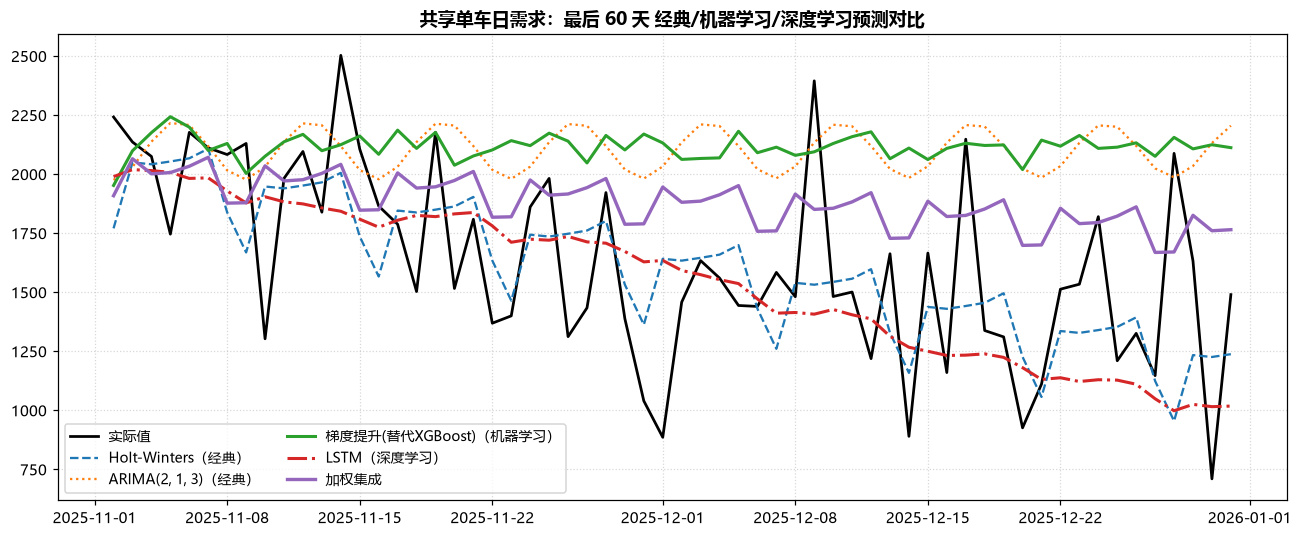

=== 全部模型：最后 60 天测试集指标（RMSE 升序）===
             模型        MAE       RMSE      MAPE
   Holt-Winters 265.957574 346.589988 17.647924
           LSTM 281.897465 373.831052 18.405261
            朴素法 356.133333 418.833817 26.115500
           加权集成 373.028109 446.402701 28.595946
 ARIMA(2, 1, 3) 519.533709 620.465244 40.335881
梯度提升(替代XGBoost) 526.970097 633.718994 41.181555


In [16]:
# 5.3 可视化：经典 vs 机器学习 vs 深度学习预测对比（论文必备插图）
plt.figure(figsize=(12, 5))
dates = df["日期"].iloc[-TEST_H:]
plt.plot(dates, y_test2.values, label="实际值", lw=1.8, color="black")
plt.plot(dates, fc_hw2.values, label="Holt-Winters（经典）", ls="--")
plt.plot(dates, fc_arima2.values, label=f"ARIMA{best2[1]}（经典）", ls=":")
plt.plot(dates, fc_ml, label=f"{ml_name}（机器学习）", lw=2.0)
plt.plot(dates, fc_lstm, label="LSTM（深度学习）", lw=2.0, ls="-.")
plt.plot(dates, ensemble, label="加权集成", lw=2.2)
plt.legend(ncol=2, fontsize=9)
plt.title("共享单车日需求：最后 60 天 经典/机器学习/深度学习预测对比", fontweight="bold")
plt.grid(ls=":", alpha=0.5); plt.tight_layout(); plt.show()

# 汇总全部模型的测试集指标，按 RMSE 排序
all_rows = [{"模型": name, **forecast_metrics(y_test2.values, fc)}
            for name, fc in [("朴素法", fc_naive), ("Holt-Winters", fc_hw2.values),
                             (f"ARIMA{best2[1]}", fc_arima2.values),
                             (ml_name, fc_ml), ("LSTM", fc_lstm), ("加权集成", ensemble)]]
all_result = pd.DataFrame(all_rows).sort_values("RMSE").reset_index(drop=True)
print("=== 全部模型：最后 60 天测试集指标（RMSE 升序）===")
print(all_result.to_string(index=False))

## 5.4 模型对比与总结

| 模型 | 复杂度 | 数据需求 | 可解释性 | 预测区间 | 适用场景 |
|------|:---:|:---:|:---:|:---:|----------|
| 朴素/移动平均 | 极低 | 极少 | 极高 | — | 基线对照 |
| 指数平滑 | 低 | 少 | 高 | 有 | 强趋势+季节 |
| ARIMA/SARIMA | 中 | 中 | 高 | 有 | 线性平稳化后序列 |
| XGBoost/LightGBM | 中高 | 较多 | 中 | 无(可估计) | 表格特征丰富 |
| LSTM/Transformer | 高 | 大 | 低 | 无 | 长序列、大数据 |
| DeepAR/N-BEATS | 高 | 大 | 低 | 有 | 概率预测 |

> 实际比赛常用组合：**基线 + 经典 + 树模型 + 加权集成**即可拿到很稳的结果；深度模型用于冲刺更高精度。

---
# 六、比赛注意事项与总结

## 6.1 高频踩坑清单（逐条核对！）

<span style="color:#c0392b">1. **未来信息泄漏**：滚动均值/滞后特征/标准化参数包含测试期数据 → 验证指标虚高，上场必炸。</span>
2. **随机 K 折**：打乱时间顺序 → 结果不可信；一律用 TimeSeriesSplit / 滚动起点。
3. **先看平稳性再选模型**：非平稳序列直接用 AR 会虚假回归；先 ADF 再差分。
4. **忘记设基线**：论文必须有 1~2 个基线模型对照，证明复杂模型的增益。
5. **残差不做诊断**：拟合完必须做 Ljung-Box 检验，不通过要重新定阶。
6. **多步预测方式不说明**：论文要写清递归/直接策略及误差累积的应对。
7. **外生变量"未来不可得"**：用天气等外生变量时，预测期必须能获取（或注明情景假设）。
8. **忽略后处理**：业务约束（非负、上限）要最后加上，模型输出不是最终答案。
9. **集成权重在测试集上算**：权重应来自验证期，测试集只做最终评估。
10. **结果不落地**：给出预测值+区间+业务建议，别只丢一个 RMSE。

## 6.2 选题与模型建议

| 数据特征 | 推荐路线 |
|----------|----------|
| 数据量小、要可解释 | 指数平滑 / ARIMA + 基线对照 |
| 表格特征丰富（天气/日历/活动） | 滑动窗口 + XGBoost/LightGBM |
| 序列长、数据量大 | LSTM / Transformer 变体（Informer 等） |
| 需要概率区间 | DeepAR / N-BEATS / 统计模型预测区间 |
| 追求稳健高分 | 多模型**加权集成** + 严格时间序列验证 |

## 6.3 论文写作要点

1. 数据处理要讲清：缺失/异常如何修，为什么这样修
2. EDA 必配图：趋势图、分解图、ACF/PACF
3. 验证方式写清楚：数据划分比例、滚动起点数、为何不用随机 K 折
4. 指标给全：MAE/RMSE/MAPE 至少两个，并附预测区间
5. 结果要对比：基线 vs 复杂模型 vs 集成，用表格+折线图呈现
6. 结论要落地：结合业务解释预测结果，给出决策建议

## 6.4 代码迁移指南

本 notebook 所有函数自包含，迁移到新问题只需：
1. 修改 `DATA_FILE` 为你自己的数据路径
2. 确认 `日期` 列格式（`parse_dates`）与目标列名
3. 按需调整季节周期 `m`（日数据取 7，月数据取 12）
4. 顺序运行：加载 → 分解/平稳性 → 基线 → 经典 → 树模型 → 集成
5. 深度学习部分按需安装 `torch`，参考 GitHub 仓库模板

**参考资源**：
- 经典模型：`statsmodels`（ARIMA、SARIMAX、ExponentialSmoothing、adfuller、acorr_ljungbox）
- 树模型：`xgboost`、`lightgbm`（GitHub 官方仓库含大量示例）
- 深度模型：GitHub 搜索 `thuml/Time-Series-Library`（Informer/Autoformer 等统一框架）、`elementai/n-beats`、`amazon-science/deepar`
- 概率预测库：`gluonts`、`darts`、`neuralforecast`